# ***车辆检测***

# 0. 要解决的问题

① 假设你正在开发自动驾驶汽车。作为该项目的重要组成部分，首先你想要构建一个车辆识别系统。

② 为了收集数据，你已经在汽车的引擎盖（即前部）上安装了摄像头，该摄像头会在车辆行驶时每隔几秒钟拍摄一次前方道路的照片。

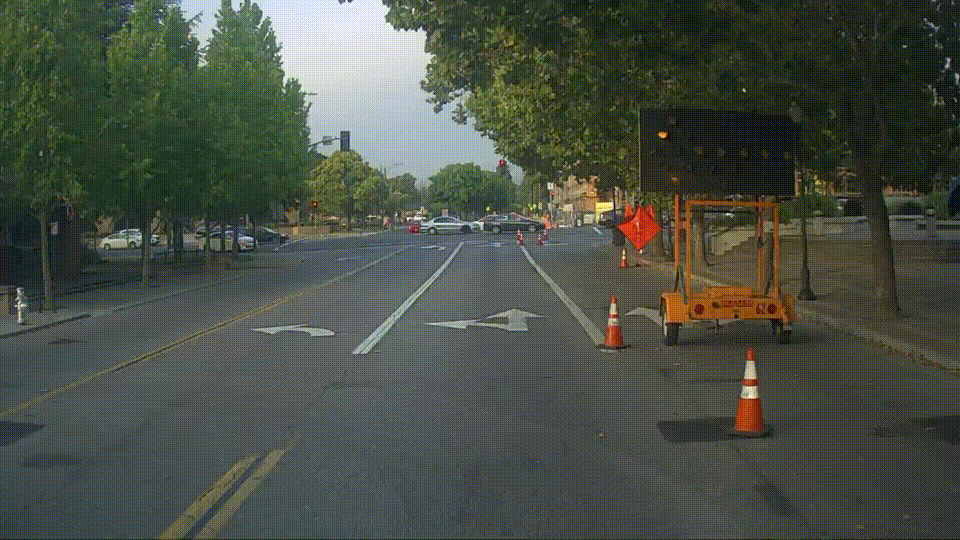

③ 这是硅谷周边的车载摄像头拍摄的照片。

④ 我们要特别感谢[drive.ai](https://www.drive.ai/)提供这个数据集！Drive.ai是一家自动驾驶汽车的公司。

① 你已将所有这些图像收集到一个文件夹中，并通过在找到的每辆汽车周围绘制边框来标记它们，下面是边界框的示例。

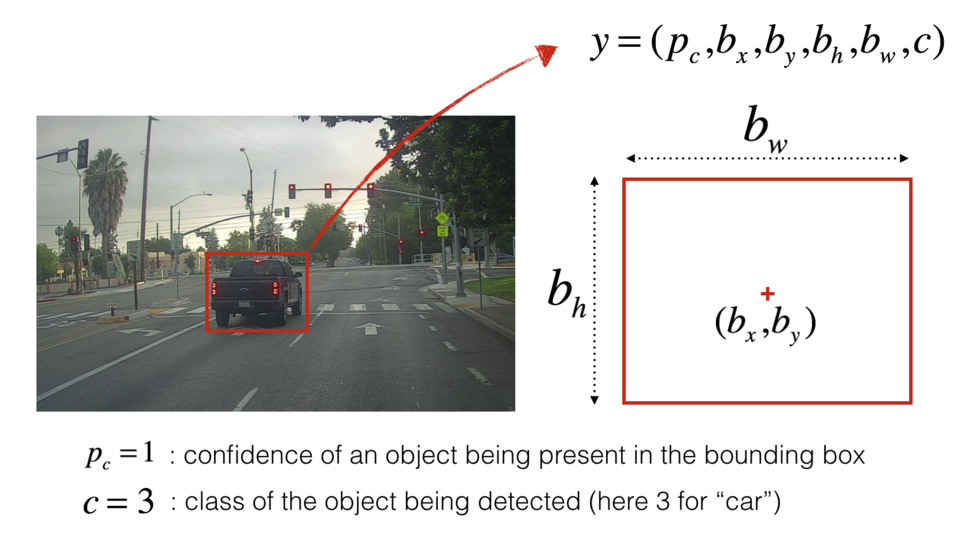

② 如果你希望YOLO识别80个类，则可以将类标签$c$表示为1到80之间的整数，或者表示为80维向量（包含80个数字），其中一个分量为1，其余均为0。在此笔记本中，我们将使用这两种表示形式，哪种方式更方便就用哪种。

③ 在本练习中，你将学习了解YOLO的工作原理，然后将其应用于车辆识别。由于训练YOLO模型需要耗费大量时间，因此我们将加载预训练的权重供你使用。

# 1. 导入库

In [1]:
import argparse
import os
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
import scipy.io
import scipy.misc
import numpy as np
import pandas as pd
import PIL
import tensorflow as tf
from keras import backend as K
from keras.layers import Input, Lambda, Conv2D
from keras.models import load_model, Model

from yad2k.models.keras_yolo import yolo_head, yolo_boxes_to_corners, preprocess_true_boxes, yolo_loss, yolo_body

import yolo_utils

%matplotlib inline

D:\11_Anaconda\envs\py3.6.3\lib\site-packages\requests\__init__.py:104: RequestsDependencyWarning: urllib3 (1.26.11) or chardet (5.0.0)/charset_normalizer (2.0.12) doesn't match a supported version!
  RequestsDependencyWarning)
Using TensorFlow backend.


# 2. YOLO

## 2.1 YOLO简介

① YOLO("you only look once")是一个很受欢迎的算法，因为它可以在实现高精度的同时能实时运行。

② 网络仅需要进行一次正向传播便可预测，因此说该算法“仅看一次图像”。

③ 在非极大值抑制之后，模型将同边界框一起输出识别到的目标。

## 2.2 模型详细信息

① 首先要知道的是：
 - 输入是一批维度为（m，608，608，3）的图像。
 - 输出是边界框和已识别的类列表。如上所述，每个边界框由6个数字$(p_c, b_x, b_y, b_h, b_w, c)$表示。如果将$c$扩展为80维向量，则每个边界框将由85个数字表示。
 
② 我们将使用5个锚框。因此，你可以将YOLO架构视为以下内容：IMAGE (m, 608, 608, 3) -> DEEP CNN -> ENCODING (m, 19, 19, 5, 85)，下图详细展示了此编码表示：

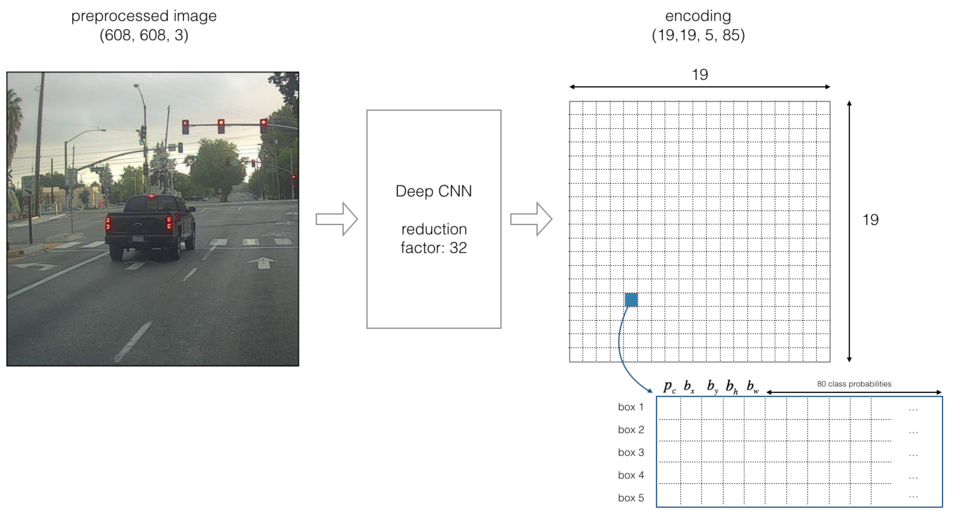

① 如果目标的中心/中点落在网格单元，则该网格单元负责识别该对象。

② 由于我们使用的是5个锚框，因此19x19单元中的每一个都对5个框的信息进行编码。锚框仅由其宽度和高度定义。

③ 为简单起见，我们将压平编码的最后两个维度（19，19，5，85），因此，CNN的输出为（19，19，425）。



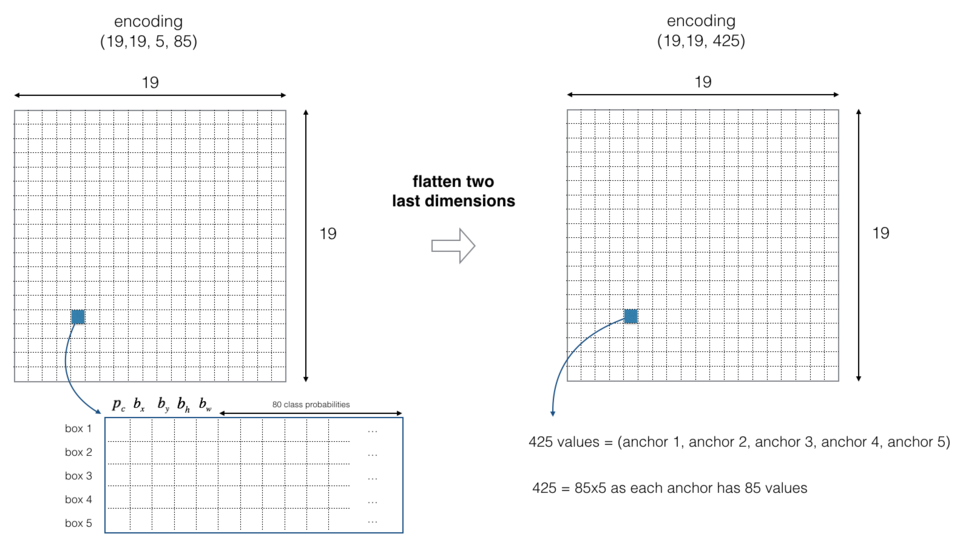

① 现在，对于（每个单元格的）每个框，我们将计算以下元素乘积，并提取该框包含某个类的概率。

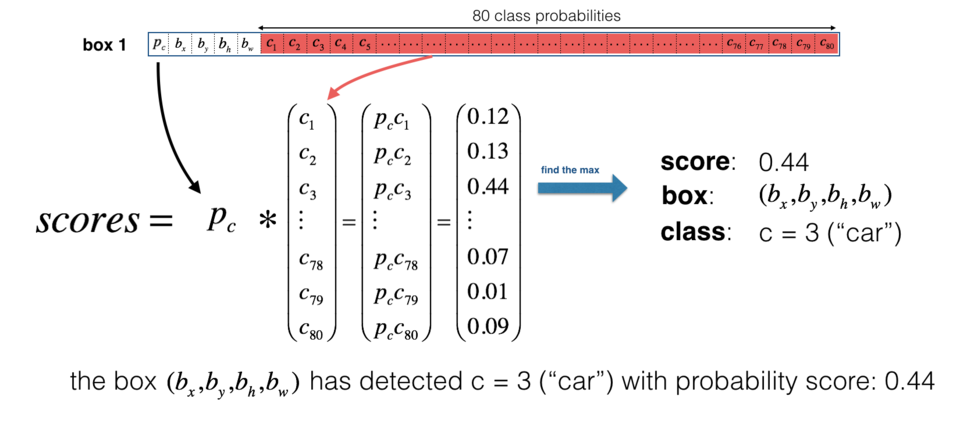

② 下面是一种可视化YOLO预测图像的方法：

 - 对于19x19的每个网格单元，找到概率得分的最大值（在5个锚点框和不同类别中均取最大值）。
 - 根据网格单元认为最可能的目标为对应的网格单元着色。

③ 执行此操作将得到以下图片：

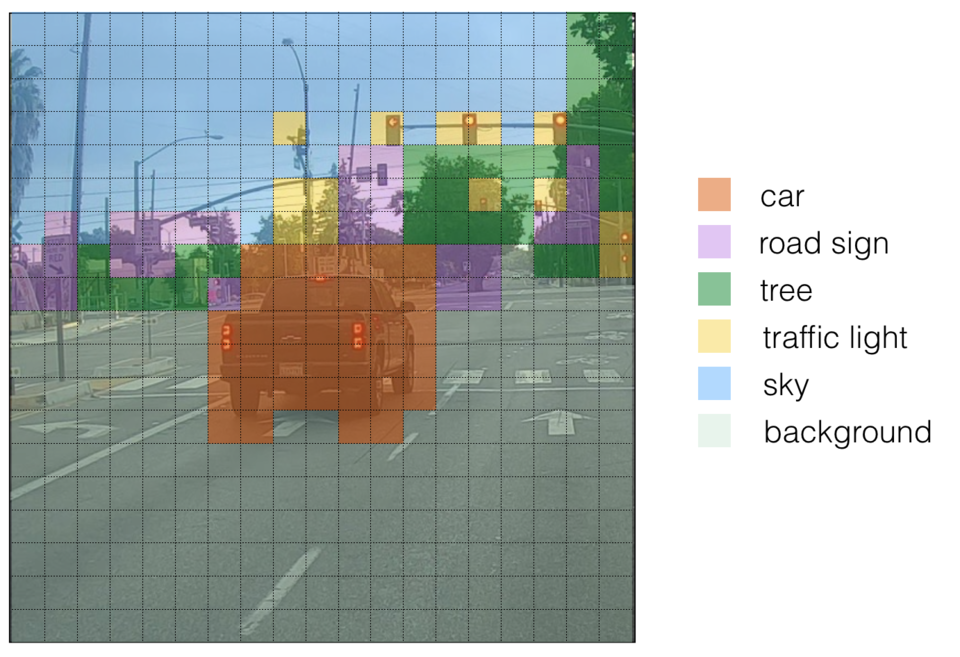

④ 请注意，这种可视化不是YOLO预测算法的核心部分。这只是可视化算法中间结果的一种好方法。

① 可视化YOLO输出的另一种方法是绘制其输出的边界框。这样做将产生如下可视化效果。

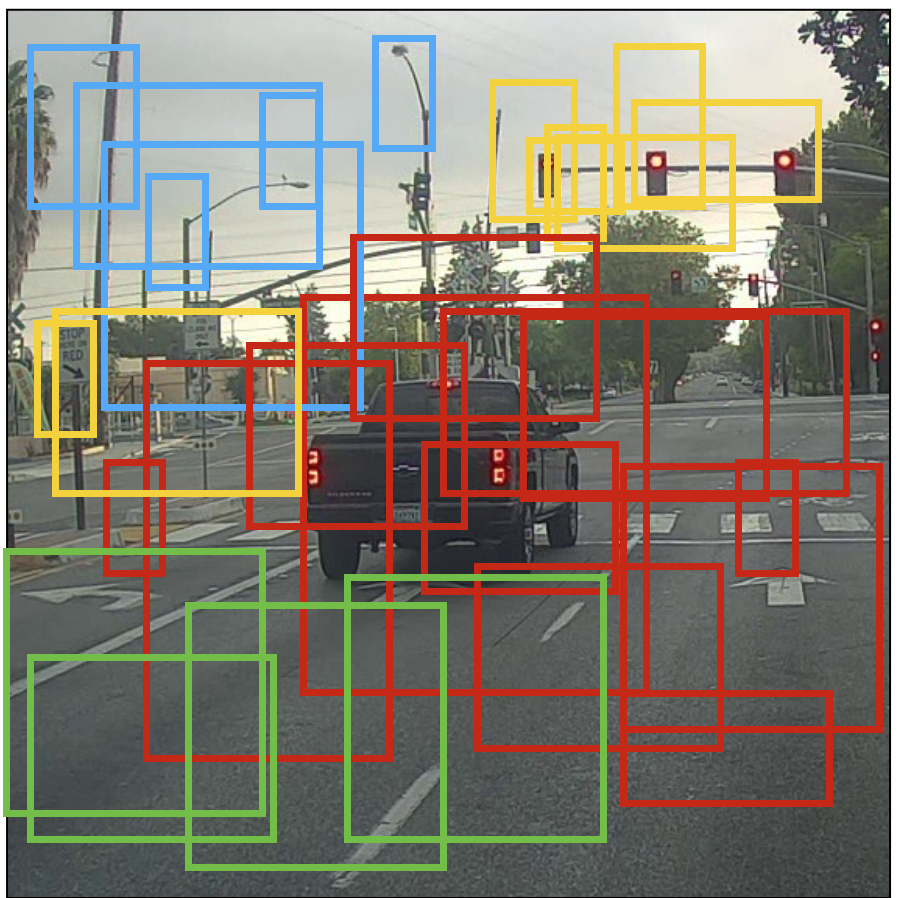

② 每个单元格给你5个方框，该模型总共预测：仅查看一次图像即可一次获得19x19x5 = 1805个框（正向传播）！不同的颜色表示不同的类别。

③ 在上图中，我们仅绘制了模型预测高概率的框，但是框仍然太多，你希望将算法的输出过滤到数量更少的目标类别。为此，你将使用非极大值抑制。具体来说，你将执行以下步骤：

 - 丢弃分数较低的盒子（这意味着盒子对检测类别不是很有信心）

 - 当多个框彼此重叠并检测到相同的目标时，仅选择一个框。

## 2.3 对类别分数进行过滤

① 你将通过阈值化应用第一个过滤器，用于丢弃类“得分”小于所选阈值的所有框。

② 该模型总共为你提供了(19x19,5,85)个数，每个框由85个数描述。

③ 将维度为(19,19,5,85) 或 (19,19,425) 的张量重新排列为以下变量将更加方便操作：

 - box_confidence：维度为$(19 \times 19, 5, 1)$的张量包含$p_c$(存在某个目标的置信概率)个19x19单元格中检测到的5个框。
 - boxes：维度为$(19 \times 19, 5, 4)$的张量都包含$(b_x, b_y, b_h, b_w)$每个单元格中的5个框。
 - box_class_probs：维度为$(19 \times 19, 5, 80)$的张量，其中包含5个框中每个单元格的80个类别的对应的检测概率$(c_1, c_2, ... c_{80})$。

① 现在我们要实现函数yolo_filter_boxes()，步骤如下：

1. 按照上图所述，通过按元素乘积计算框的分数。以下代码可以帮助你选择合适的运算符：
 - a = np.random.randn(19x19,5,1) #p_c
 - b = np.random.randn(19x19,5,80) #c_1 ~ c_80
 - c = a * b #计算后的维度将会是(19x19,5,80)
 
2. 对于每个框，找到：
 - 具有最大值的框的类别索引(请注意选择的轴；考虑使用axis = -1)
 - 相应的框分数(请注意选择的轴；考虑使用axis = -1)
   
3. 使用阈值创建mask。提醒一下：([0.9, 0.3, 0.4, 0.5, 0.1] < 0.4) 会返回：[False, True, False, False, True]。对于要保留的框，mask应该为True。

4. 使用TensorFlow将mask应用于box_class_scores，box和box_classes，以过滤掉我们不需要的框。你应该只剩下要保留的部分框。

In [2]:
a = np.random.randn(19 * 19,5,1) #p_c
b = np.random.randn(19 * 19,5,80) #c_1 ~ c_80
c = a * b #计算后的维度将会是(19x19,5,80)

In [3]:
def yolo_filter_boxes(box_confidence , boxes, box_class_probs, threshold = 0.6):
    """
    通过阈值来过滤对象和分类的置信度。
    
    参数：
        box_confidence  - tensor类型，维度为（19,19,5,1）,包含19x19单元格中每个单元格预测的5个锚框中的所有的锚框的pc （一些对象的置信概率）。
        boxes - tensor类型，维度为(19,19,5,4)，包含了所有的锚框的（px,py,ph,pw ）。
        box_class_probs - tensor类型，维度为(19,19,5,80)，包含了所有单元格中所有锚框的所有对象( c1,c2,c3，···，c80 )检测的概率。
        threshold - 实数，阈值，如果分类预测的概率高于它，那么这个分类预测的概率就会被保留。
    
    返回：
        scores - tensor 类型，维度为(None,)，包含了保留了的锚框的分类概率。
        boxes - tensor 类型，维度为(None,4)，包含了保留了的锚框的(b_x, b_y, b_h, b_w)
        classess - tensor 类型，维度为(None,)，包含了保留了的锚框的索引
        
    注意："None"是因为你不知道所选框的确切数量，因为它取决于阈值。
          比如：如果有10个锚框，scores的实际输出大小将是（10,）
    """
    
    #第一步：计算锚框的得分
    box_scores  = box_confidence * box_class_probs
    
    #第二步：找到最大值的锚框的索引以及对应的最大值的锚框的分数
    box_classes = K.argmax(box_scores, axis=-1)
    box_class_scores = K.max(box_scores, axis=-1)
    
    #第三步：根据阈值创建掩码
    filtering_mask = (box_class_scores >= threshold)
    
    #对scores, boxes 以及 classes使用掩码
    scores = tf.boolean_mask(box_class_scores,filtering_mask)
    boxes = tf.boolean_mask(boxes,filtering_mask)
    classes = tf.boolean_mask(box_classes,filtering_mask)
    
    return scores , boxes , classes

In [4]:
print("=====我们来测试一下======")
with tf.Session() as test_a:
    box_confidence = tf.random_normal([19,19,5,1], mean=1, stddev=4, seed=1)
    boxes = tf.random_normal([19,19,5,4],  mean=1, stddev=4, seed=1)
    box_class_probs = tf.random_normal([19, 19, 5, 80], mean=1, stddev=4, seed = 1)
    scores, boxes, classes = yolo_filter_boxes(box_confidence, boxes, box_class_probs, threshold = 0.5)
    
    print("scores[2] = " + str(scores[2].eval()))
    print("boxes[2] = " + str(boxes[2].eval()))
    print("classes[2] = " + str(classes[2].eval()))
    print("scores.shape = " + str(scores.shape))
    print("boxes.shape = " + str(boxes.shape))
    print("classes.shape = " + str(classes.shape))
    
    test_a.close()

=====我们来测试一下======
scores[2] = 10.750582
boxes[2] = [ 8.426533   3.2713668 -0.5313436 -4.9413733]
classes[2] = 7
scores.shape = (?,)
boxes.shape = (?, 4)
classes.shape = (?,)


## 2.4 非极大值抑制

① 即使是我们通过阈值来过滤了一些得分较低的分类，但是我们依旧会有很多的锚框被留了下来，第二个过滤器就是让下图左边变为右边，我们叫它非极大值抑制(non-maximum suppression(NMS))。

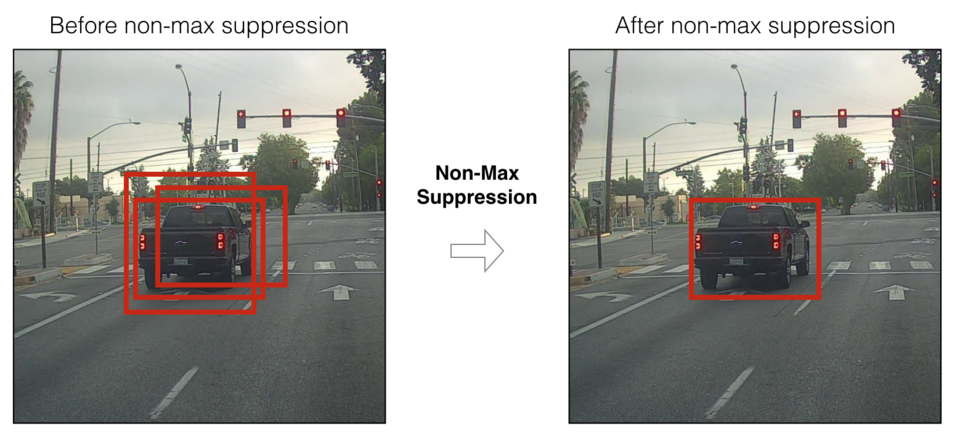

② 在此示例中，该模型检测到了3辆汽车，但实际上是同一辆汽车的3个预测结果。运行非极大值抑制（NMS）将仅选择三个框中最准确的（概率最高）一个。

① 非极大值抑制使用非常重要的函数，即 "Intersection over Union" 或者说IoU。

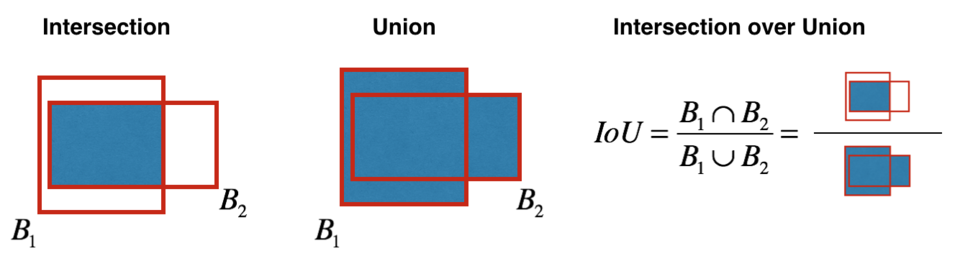

② 现在我们要实现交并比函数iou()，步骤如下：

 - 在这里，我们要使用左上和右下角来定义方框(x1，y1，x2，y2)而不是使用中点+宽高的方式定义。
 - 要计算矩形的面积，你需要将高度（y2-y1）乘以其宽度（x2-x1）
 - 你还需要找到两个框的交点的坐标$（x^i_1，y^i_1，x^i_2，y^i_2）$。记住：
    - $x^i_1$ = 两个锚框的x1坐标的最大值
    - $y^i_1$ = 两个锚框的y1坐标的最大值
    - $x^i_2$ = 两个锚框的x2坐标的最小值
    - $y^i_2$ = 两个锚框的y2坐标的最小值
    
③ 在代码中，我们为了方便把图片的左上角定为(0,0)，右上角为(1,0)，左下角为(0,1)，右下角为(1,1)。

In [5]:
def iou(box1, box2):
    """
    实现两个锚框的交并比的计算
    
    参数：
        box1 - 第一个锚框，元组类型，(x1, y1, x2, y2)
        box2 - 第二个锚框，元组类型，(x1, y1, x2, y2)
    
    返回：
        iou - 实数，交并比。
    """
    #计算相交的区域的面积
    xi1 = np.maximum(box1[0], box2[0])
    yi1 = np.maximum(box1[1], box2[1])
    xi2 = np.minimum(box1[2], box2[2])
    yi2 = np.minimum(box1[3], box2[3])
    inter_area = (xi1-xi2)*(yi1-yi2)
    
    #计算并集，公式为：Union(A,B) = A + B - Inter(A,B)
    box1_area = (box1[2]-box1[0])*(box1[3]-box1[1])
    box2_area = (box2[2]-box2[0])*(box2[3]-box2[1])
    union_area = box1_area + box2_area - inter_area
    
    #计算交并比
    iou = inter_area / union_area
    
    return iou

In [6]:
print("=====我们来测试一下======")
box1 = (2,1,4,3)
box2 = (1,2,3,4)
print("iou = " + str(iou(box1, box2)))

=====我们来测试一下======
iou = 0.14285714285714285


① 现在你可以实现非极大值抑制，其关键步骤是：
 1. 选择得分最高的框。
 2. 计算它与所有其他框的重叠，并删除与其重叠超过“iou_threshold”的框。
 3. 返回到步骤1并进行迭代，直到没有比当前所选框更低的框。

② 这将删除所有与所选框重叠较大的框。仅保留“最佳”框。

① 我们要实现的函数名为yolo_non_max_suppression()，使用TensorFlow实现，TensorFlow有两个内置函数用于实现非最大抑制（所以你实际上不需要使用你的iou()实现）：
 - tf.image.non_max_suppression()
 - K.gather()

In [7]:
def yolo_non_max_suppression(scores, boxes, classes, max_boxes=10, iou_threshold=0.5):
    """
    为锚框实现非最大值抑制（ Non-max suppression (NMS)）
    
    参数：
        scores - tensor类型，维度为(None,)，yolo_filter_boxes()的输出
        boxes - tensor类型，维度为(None,4)，yolo_filter_boxes()的输出，已缩放到图像大小（见下文）
        classes - tensor类型，维度为(None,)，yolo_filter_boxes()的输出
        max_boxes - 整数，预测的锚框数量的最大值
        iou_threshold - 实数，交并比阈值。
        
    返回：
        scores - tensor类型，维度为(,None)，每个锚框的预测的可能值
        boxes - tensor类型，维度为(4,None)，预测的锚框的坐标
        classes - tensor类型，维度为(,None)，每个锚框的预测的分类
        
    注意："None"是明显小于max_boxes的，这个函数也会改变scores、boxes、classes的维度，这会为下一步操作提供方便。
    
    """
    max_boxes_tensor = K.variable(max_boxes,dtype="int32") #用于tf.image.non_max_suppression()
    K.get_session().run(tf.variables_initializer([max_boxes_tensor])) #初始化变量max_boxes_tensor
    
    #使用使用tf.image.non_max_suppression()来获取与我们保留的框相对应的索引列表
    nms_indices = tf.image.non_max_suppression(boxes, scores,max_boxes,iou_threshold)
    
    #使用K.gather()来选择保留的锚框
    scores = K.gather(scores, nms_indices)
    boxes = K.gather(boxes, nms_indices)
    classes = K.gather(classes, nms_indices)
    
    return scores, boxes, classes

In [8]:
print("=====我们来测试一下======")
with tf.Session() as test_b:
    scores = tf.random_normal([54,], mean=1, stddev=4, seed = 1)
    boxes = tf.random_normal([54, 4], mean=1, stddev=4, seed = 1)
    classes = tf.random_normal([54,], mean=1, stddev=4, seed = 1)
    scores, boxes, classes = yolo_non_max_suppression(scores, boxes, classes)
    
    print("scores[2] = " + str(scores[2].eval()))
    print("boxes[2] = " + str(boxes[2].eval()))
    print("classes[2] = " + str(classes[2].eval()))
    print("scores.shape = " + str(scores.eval().shape))
    print("boxes.shape = " + str(boxes.eval().shape))
    print("classes.shape = " + str(classes.eval().shape))
    
    test_b.close()

=====我们来测试一下======
scores[2] = 6.938395
boxes[2] = [-5.299932    3.1379814   4.450367    0.95942086]
classes[2] = -2.2452729
scores.shape = (10,)
boxes.shape = (10, 4)
classes.shape = (10,)


## 2.5 对所有框进行过滤

① 现在我们要实现一个CNN（19x19x5x85）输出的函数，并使用刚刚实现的函数对所有框进行过滤。

② 我们要实现的函数名为yolo_eval()，它采用YOLO编码的输出，并使用分数阈值和NMS来过滤这些框。

③ 你只需要了解最后一个实现细节。有几种表示框的方法，例如通过它们的角或中点和高度/宽度。

④ YOLO使用以下函数（我们已提供）在不同时间内在这几种类格式之间进行转换：

 - boxes = yolo_boxes_to_corners(box_xy, box_wh)
 
⑤ 它将yolo锚框坐标（x，y，w，h）转换为角的坐标（x1，y1，x2，y2）以匹配yolo_filter_boxes()的输入。

 - boxes = yolo_utils.scale_boxes(boxes, image_shape)
 
⑥ YOLO的网络经过训练可以在608x608图像上运行。如果你要在不同大小的图像上测试此数据（例如，汽车检测数据集具有720x1280图像），则此步骤会重新缩放这些框，以便在原始的720x1280图像上绘制它们。

In [9]:
def yolo_eval(yolo_outputs, image_shape=(720.,1280.), 
              max_boxes=10, score_threshold=0.6,iou_threshold=0.5):
    """
    将YOLO编码的输出（很多锚框）转换为预测框以及它们的分数，框坐标和类。
    
    参数：
        yolo_outputs - 编码模型的输出（对于维度为（608,608,3）的图片），包含4个tensors类型的变量：
                        box_confidence ： tensor类型，维度为(None, 19, 19, 5, 1)
                        box_xy         ： tensor类型，维度为(None, 19, 19, 5, 2)
                        box_wh         ： tensor类型，维度为(None, 19, 19, 5, 2)
                        box_class_probs： tensor类型，维度为(None, 19, 19, 5, 80)
        image_shape - tensor类型，维度为（2,），包含了输入的图像的维度，这里是(608.,608.)
        max_boxes - 整数，预测的锚框数量的最大值
        score_threshold - 实数，可能性阈值。
        iou_threshold - 实数，交并比阈值。
        
    返回：
        scores - tensor类型，维度为(,None)，每个锚框的预测的可能值
        boxes - tensor类型，维度为(4,None)，预测的锚框的坐标
        classes - tensor类型，维度为(,None)，每个锚框的预测的分类
    """
    
    #获取YOLO模型的输出
    box_confidence, box_xy, box_wh, box_class_probs = yolo_outputs
    
    #中心点转换为边角
    boxes = yolo_boxes_to_corners(box_xy,box_wh)
    
    #可信度分值过滤
    scores, boxes, classes = yolo_filter_boxes(box_confidence, boxes, box_class_probs, score_threshold)
    
    #缩放锚框，以适应原始图像
    boxes = yolo_utils.scale_boxes(boxes, image_shape)
    
    #使用非最大值抑制
    scores, boxes, classes = yolo_non_max_suppression(scores, boxes, classes, max_boxes, iou_threshold)
    
    return scores, boxes, classes

In [10]:
print("=====我们来测试一下======")
with tf.Session() as test_c:
    yolo_outputs = (tf.random_normal([19, 19, 5, 1], mean=1, stddev=4, seed = 1),
                    tf.random_normal([19, 19, 5, 2], mean=1, stddev=4, seed = 1),
                    tf.random_normal([19, 19, 5, 2], mean=1, stddev=4, seed = 1),
                    tf.random_normal([19, 19, 5, 80], mean=1, stddev=4, seed = 1))
    scores, boxes, classes = yolo_eval(yolo_outputs)
    
    print("scores[2] = " + str(scores[2].eval()))
    print("boxes[2] = " + str(boxes[2].eval()))
    print("classes[2] = " + str(classes[2].eval()))
    print("scores.shape = " + str(scores.eval().shape))
    print("boxes.shape = " + str(boxes.eval().shape))
    print("classes.shape = " + str(classes.eval().shape))
    
    test_c.close()

=====我们来测试一下======
scores[2] = 138.79124
boxes[2] = [1292.3297  -278.52167 3876.9893  -835.56494]
classes[2] = 54
scores.shape = (10,)
boxes.shape = (10, 4)
classes.shape = (10,)


① YOLO总结：

 - 输入图像维度为（608、608、3）。
 - 输入图像通过CNN，输出维度为（19,19,5,85）。
 - 将最后两个维度展平后，输出为一定体积的形状（19、19、425）：
   - 输入图像上方19x19网格中的每个单元格给出425个数字。
   - 425 = 5 x 85，因为每个单元格都包含5个预测框，对应于5个锚定框，如讲座中所示。
   - 85 = 5 + 80，其中5是因为$(p_c, b_x, b_y, b_h, b_w)$具有5个数，而80是我们要识别的类别数量。
 - 然后，你仅根据以下几点选择框：
   - 分数阈值：丢弃检测到分数小于阈值的类别框。
   - 非极大值抑制：计算并集上的交点，并避免选择重叠的框。
 - 为你提供YOLO的最终输出。

# 3. 输入图像测试YOLO预训练模型

① 在本部分中，你将使用预训练的模型并在车辆识别数据集上对其进行测试。

② 像往常一样，首先创建一个会话来启动计算图。

In [11]:
sess = K.get_session()

## 3.1 定义分类、锚框与图像维度

① 回想一下我们在试着分类80个类别，使用5个锚框。我们收集了两个文件“coco_classes.txt”和“yolo_anchors.txt”中关于80个类和5个锚框的信息。

② 我们将这些数据加载到模型中。

In [12]:
class_names = yolo_utils.read_classes("datasets/coco_classes.txt")
anchors = yolo_utils.read_anchors("datasets/yolo_anchors.txt")
image_shape = (720.,1280.)

## 3.2 加载已经训练好了的模型

① 训练YOLO模型需要很长时间，并且需要一个相当大的标签边界框数据集，用于大范围的目标类。

② 我们将加载存储在“yolov2.h5”中的现有预训练Keras YOLO模型。(这些权值来自官方YOLO网站，并使用Allan Zelener编写的函数进行转换，从技术上讲，这些参数来自“YOLOv2”模型。


In [13]:
# 如果报错'str' object has no attribute 'decode'  就把h5py安装2.10版本
# pip install h5py==2.10 -i https://pypi.doubanio.com/simple
yolo_model = load_model("datasets/yolov2.h5") 

D:\11_Anaconda\envs\py3.6.3\lib\site-packages\keras\models.py:255: UserWarning: No training configuration found in save file: the model was *not* compiled. Compile it manually.
  warnings.warn('No training configuration found in save file: '


③ 这会加载训练的YOLO模型的权重, 以下是模型包含的图层的摘要。

In [14]:
yolo_model.summary()

__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            (None, 608, 608, 3)  0                                            
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 608, 608, 32) 864         input_1[0][0]                    
__________________________________________________________________________________________________
batch_normalization_1 (BatchNor (None, 608, 608, 32) 128         conv2d_1[0][0]                   
__________________________________________________________________________________________________
leaky_re_lu_1 (LeakyReLU)       (None, 608, 608, 32) 0           batch_normalization_1[0][0]      
__________________________________________________________________________________________________
max_poolin

④ 在某些电脑上，可能会看到来自Keras的警告消息，不要担心，这个没有什么问题的。

⑤ 该模型将预处理的一批输入图像（shape：（m，608,608,3））转换为tensor类型，维度为（m，19,19,5,85）。

## 3.3 将模型的输出转换为边界框

① yolo_model的输出是一个（m，19,19,5,85）的tensor变量，它需要进行处理和转换。

In [15]:
yolo_outputs = yolo_head(yolo_model.output, anchors, len(class_names))

② 现在你已经把yolo_outputs添加进了计算图中，这4个tensor变量已准备好用作yolo_eval函数的输入。

## 3.4 过滤锚框

① yolo_outputs已经正确的格式为我们提供了yolo_model的所有预测框，我们现在已准备好执行过滤并仅选择最佳的锚框。

② 现在让我们调用之前实现的yolo_eval()。

In [16]:
scores, boxes, classes = yolo_eval(yolo_outputs, image_shape)

## 3.5 在实际图像中运行计算图

① 我们之前已经创建了一个用于会话的sess，这里有一些回顾：

 - yolo_model.input是yolo_model的输入，yolo_model.output是yolo_model的输出。
 - yolo_model.output会让yolo_head进行处理，这个函数最后输出yolo_outputs
 - yolo_outputs会让一个过滤函数yolo_eval进行处理，然后输出预测：scores、 boxes、 classes

② 现在我们要实现predict()函数，使用它来对图像进行预测，我们需要运行TensorFlow的Session会话，然后在计算图上计算scores、 boxes、 classes，下面的代码可以帮你预处理图像：

 - image：用于绘制框的图像的Python（PIL）表示，这里你不需要使用它。

 - image_data：图像的numpy数组，这将是CNN的输入。

③ 请注意，当模型使用BatchNorm（比如YOLO中的情况）时，您需要在feed_dict {K.learning_phase()：0}中传递一个额外的占位符。

In [17]:
'image, image_data = yolo_utils.preprocess_image("images/" + image_file, model_image_size = (608, 608))'    

'image, image_data = yolo_utils.preprocess_image("images/" + image_file, model_image_size = (608, 608))'

In [18]:
def predict(sess, image_file, is_show_info=True, is_plot=True):
    """
    运行存储在sess的计算图以预测image_file的边界框，打印出预测的图与信息。
    
    参数：
        sess - 包含了YOLO计算图的TensorFlow/Keras的会话。
        image_file - 存储在images文件夹下的图片名称
    返回：
        out_scores - tensor类型，维度为(None,)，锚框的预测的可能值。
        out_boxes - tensor类型，维度为(None,4)，包含了锚框位置信息。
        out_classes - tensor类型，维度为(None,)，锚框的预测的分类索引。 
    """
    #图像预处理
    image, image_data = yolo_utils.preprocess_image("images/" + image_file, model_image_size = (608, 608))
    
    #运行会话并在feed_dict中选择正确的占位符.
    out_scores, out_boxes, out_classes = sess.run([scores, boxes, classes], feed_dict = {yolo_model.input:image_data, K.learning_phase(): 0})
    
    #打印预测信息
    if is_show_info:
        print("在" + str(image_file) + "中找到了" + str(len(out_boxes)) + "个锚框。")
    
    #指定要绘制的边界框的颜色
    colors = yolo_utils.generate_colors(class_names)
    
    #在图中绘制边界框
    yolo_utils.draw_boxes(image, out_scores, out_boxes, out_classes, class_names, colors)
    
    #保存已经绘制了边界框的图
    image.save(os.path.join("out", image_file), quality=100)
    
    #打印出已经绘制了边界框的图
    if is_plot:
        output_image = scipy.misc.imread(os.path.join("out", image_file))
        plt.imshow(output_image)
    
    return out_scores, out_boxes, out_classes

在test.jpg中找到了7个锚框。
car 0.60 (925, 285) (1045, 374)
bus 0.67 (5, 267) (220, 407)
car 0.68 (705, 279) (786, 351)
car 0.70 (947, 324) (1280, 704)
car 0.75 (159, 303) (346, 440)
car 0.80 (762, 282) (942, 412)
car 0.89 (366, 299) (745, 648)


D:\11_Anaconda\envs\py3.6.3\lib\site-packages\ipykernel_launcher.py:34: DeprecationWarning: `imread` is deprecated!
`imread` is deprecated in SciPy 1.0.0, and will be removed in 1.2.0.
Use ``imageio.imread`` instead.


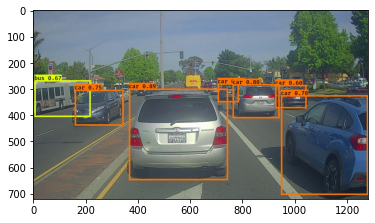

In [19]:
out_scores, out_boxes, out_classes = predict(sess, "test.jpg")

## 3.6 批量绘制图

① 我们可以看到在images文件夹中有从"0001.jpg"到"0120.jpg"的图，我们现在就把它们全部绘制出来。

当前文件：0001.jpg
在0001.jpg中找到了0个锚框。
当前文件：0002.jpg


D:\11_Anaconda\envs\py3.6.3\lib\site-packages\ipykernel_launcher.py:34: DeprecationWarning: `imread` is deprecated!
`imread` is deprecated in SciPy 1.0.0, and will be removed in 1.2.0.
Use ``imageio.imread`` instead.


在0002.jpg中找到了0个锚框。
当前文件：0003.jpg
在0003.jpg中找到了3个锚框。
car 0.69 (347, 289) (445, 321)
car 0.70 (230, 307) (318, 354)
car 0.73 (671, 284) (770, 315)
当前文件：0004.jpg
在0004.jpg中找到了4个锚框。
car 0.63 (400, 285) (514, 327)
car 0.66 (95, 297) (227, 342)
car 0.68 (1, 321) (121, 410)
car 0.73 (539, 277) (659, 318)
当前文件：0005.jpg
在0005.jpg中找到了5个锚框。
car 0.64 (207, 297) (338, 340)
car 0.64 (741, 266) (918, 313)
car 0.67 (15, 313) (128, 362)
car 0.72 (883, 260) (1026, 303)
car 0.76 (518, 282) (689, 336)
当前文件：0006.jpg
在0006.jpg中找到了2个锚框。
car 0.72 (72, 320) (220, 367)
car 0.72 (470, 286) (687, 343)
当前文件：0007.jpg
在0007.jpg中找到了2个锚框。
car 0.67 (1087, 243) (1226, 312)
car 0.78 (468, 292) (685, 353)
当前文件：0008.jpg
在0008.jpg中找到了2个锚框。
truck 0.63 (852, 252) (1084, 330)
car 0.78 (1083, 275) (1276, 340)
当前文件：0009.jpg
在0009.jpg中找到了0个锚框。
当前文件：0010.jpg
在0010.jpg中找到了1个锚框。
truck 0.66 (736, 266) (1053, 368)
当前文件：0011.jpg
在0011.jpg中找到了2个锚框。
truck 0.73 (727, 269) (1054, 376)
car 0.85 (6, 336) (211, 457)
当前文件：0012.jpg
在0012.jpg中找到

在0105.jpg中找到了0个锚框。
当前文件：0106.jpg
在0106.jpg中找到了1个锚框。
car 0.62 (1200, 287) (1276, 432)
当前文件：0107.jpg
在0107.jpg中找到了1个锚框。
car 0.61 (376, 309) (421, 335)
当前文件：0108.jpg
在0108.jpg中找到了0个锚框。
当前文件：0109.jpg
在0109.jpg中找到了0个锚框。
当前文件：0110.jpg
在0110.jpg中找到了0个锚框。
当前文件：0111.jpg
在0111.jpg中找到了2个锚框。
car 0.61 (97, 322) (180, 366)
fire hydrant 0.64 (1177, 374) (1237, 483)
当前文件：0112.jpg
在0112.jpg中找到了0个锚框。
当前文件：0113.jpg
在0113.jpg中找到了0个锚框。
当前文件：0114.jpg
在0114.jpg中找到了0个锚框。
当前文件：0115.jpg
在0115.jpg中找到了0个锚框。
当前文件：0116.jpg
在0116.jpg中找到了2个锚框。
traffic light 0.63 (522, 76) (543, 113)
car 0.80 (5, 271) (241, 671)
当前文件：0117.jpg
在0117.jpg中找到了0个锚框。
当前文件：0118.jpg
在0118.jpg中找到了0个锚框。
当前文件：0119.jpg
在0119.jpg中找到了1个锚框。
traffic light 0.61 (1056, 0) (1138, 131)
当前文件：0120.jpg
在0120.jpg中找到了0个锚框。
绘制完成！


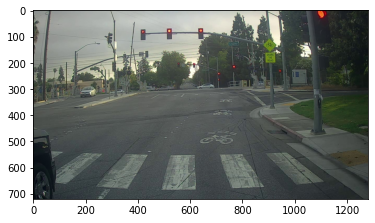

In [20]:
for i in range(1,121):
    
    #计算需要在前面填充几个0
    num_fill = int( len("0000") - len(str(1))) + 1
    #对索引进行填充
    filename = str(i).zfill(num_fill) + ".jpg"
    print("当前文件：" + str(filename))
    
    #开始绘制，打印信息，绘制图（输入在images文件夹内，输出在out文件夹内）
    out_scores, out_boxes, out_classes = predict(sess, filename,is_show_info=True,is_plot=True)
    
print("绘制完成！")